In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")
sns.set_palette([sns.color_palette()[i] for i in [0, 1, 2, 4, 4, 0, 1, 5]])

data = pd.read_csv("latency-nots-cpu.csv")
data["Speedup"] = 0

models = set(data["Model"])
passes = set(data["Pass"])
frameworks = set(data["Framework"])
base_framework = "TF-XLA"

#### still use comparison, cannot measure other LLM on CPU

In [2]:
for model in models:
    for pas in passes:
        base = data.loc[
            (data["Model"] == model) & 
            (data["Pass"] == pas) & 
            (data["Framework"] == base_framework), 
            "Time"
        ].item()
        for framework in frameworks:
            time = data.loc[
                (data["Model"] == model) & 
                (data["Pass"] == pas) & 
                (data["Framework"] == framework), 
                "Time"
            ].item()
            data.loc[
                (data["Model"] == model) & 
                (data["Pass"] == pas) & 
                (data["Framework"] == framework), 
                "Speedup"
            ] = base / time
            
gradient_data = data[data["Pass"] == "Gradient"]
total_data = data[data["Pass"] == "Total"]
print(total_data)

          Time   Pass               Model    Framework   Speedup
8    24.904834  Total           ResNet152  TorchDynamo  0.875775
9    21.811020  Total           ResNet152       TF-XLA  1.000000
10   27.026660  Total           ResNet152          JAX  0.807019
11   18.361000  Total           ResNet152  Nabla Optim  1.187899
20   19.618990  Total           ResNet101  TorchDynamo  1.286808
21   25.245870  Total           ResNet101       TF-XLA  1.000000
22   19.429650  Total           ResNet101          JAX  1.299348
23   14.272638  Total           ResNet101  Nabla Optim  1.768830
32   23.732392  Total       WideResNet101  TorchDynamo  1.795382
33   42.608700  Total       WideResNet101       TF-XLA  1.000000
34   26.513160  Total       WideResNet101          JAX  1.607077
35   23.848488  Total       WideResNet101  Nabla Optim  1.786642
44   13.449026  Total               VGG16  TorchDynamo  1.245447
45   16.750050  Total               VGG16       TF-XLA  1.000000
46   13.312050  Total    

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39


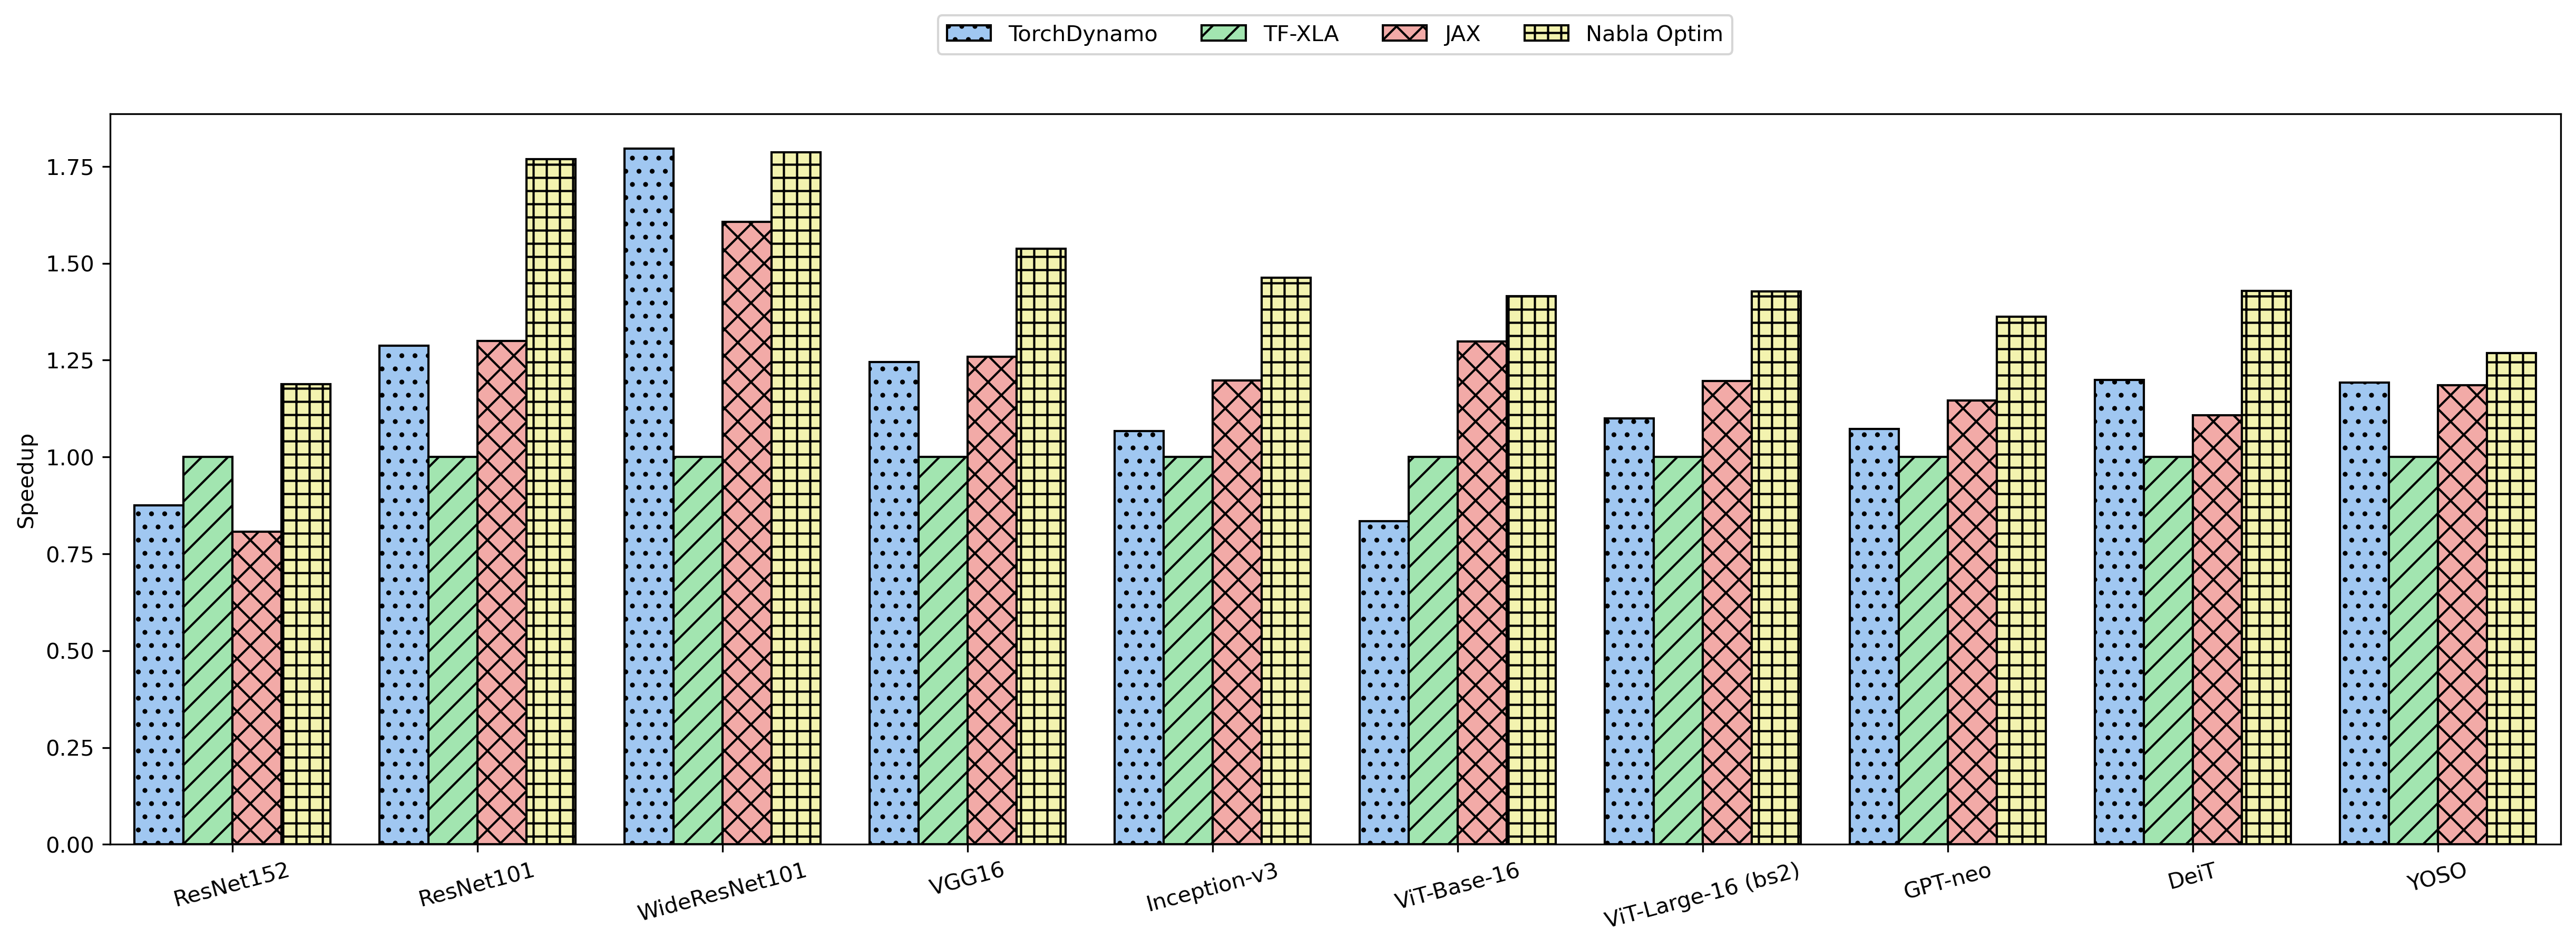

In [3]:
plt.rcParams["figure.figsize"] = (len(models) * 2, 6)

hatches = ["//", "xx", "++", ".."]
assert len(hatches) == len(frameworks)

barplot = sns.barplot(total_data, x="Model", y="Speedup", hue="Framework")
plt.xticks(rotation=15)
plt.xlabel(None)

for i, bar in enumerate(barplot.patches):
    print(i)
    bar.set_hatch(hatches[i // len(models)-1])
    bar.set_edgecolor("black")
    
legend = plt.legend(loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.15))

# plt.savefig("gradient.pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)